#**Research Project**
##**Check how age and gender affect ASD (Toddlers Dataset)**

###Conducted by Christel AL HAGE
###With the supervision of Dr. Mounim EL YACOUBI and Dr. Jihyun MUN

Dataset used:
https://www.kaggle.com/datasets/ajithdari/early-autism-screening-dataset-for-toddlers

**Step 1: Setup and Data Preprocessing**

In [ ]:
!pip install shap xgboost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load the dataset
df = pd.read_csv('toddler_autism.csv')

# Define our exact columns
features = [
    'Language_Delay', 'Social_Interaction_Score',
    'Communication_Score', 'Repetitive_Behavior_Score',
    'Age', 'Gender', 'Jaundice', 'Family_ASD_History'
]
target_col = 'Diagnosed_ASD'

# Clean and encode the data (handling any text/objects)
encoder = LabelEncoder()
for col in features + [target_col]:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col].astype(str))
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Split the data
X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 2: Train the XGBoost Model & Evaluate Demographics**

In [ ]:
# XGBoost handles class imbalance natively with scale_pos_weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=pos_weight,
    random_state=42
)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)
print(f"--- Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}% ---\n")

# Stratified Demographic Analysis
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

print("--- Accuracy by Gender (0=Female, 1=Male) ---")
print(results_df.groupby('Gender').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))

print("\n--- Accuracy by Age Group ---")
results_df['Age_Group'] = pd.cut(results_df['Age'], bins=[11, 18, 24, 30, 36])
print(results_df.groupby('Age_Group').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))

--- Overall Model Accuracy: 46.00% ---

--- Accuracy by Gender (0=Female, 1=Male) ---
Gender
0    42.718447
1    49.484536
dtype: float64

--- Accuracy by Age Group ---
Age_Group
(11, 18]    40.322581
(18, 24]    56.756757
(24, 30]    38.461538
(30, 36]    53.061224
dtype: float64


/tmp/ipykernel_1964/3636703577.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(results_df.groupby('Gender').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))
/tmp/ipykernel_1964/3636703577.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby('Age_Group').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))
/tmp/ipykernel_1964/3636703577.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depr

**Step 3: Generate SHAP Plots**

Generating SHAP Summary Plot...


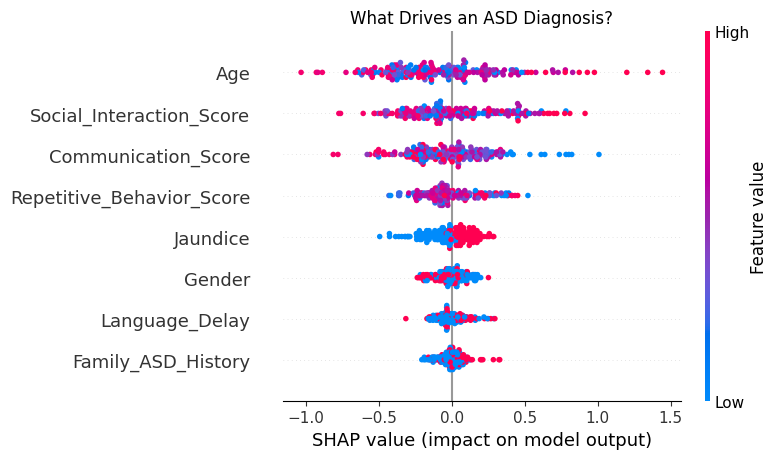


Generating Age vs. Communication Interaction Plot...


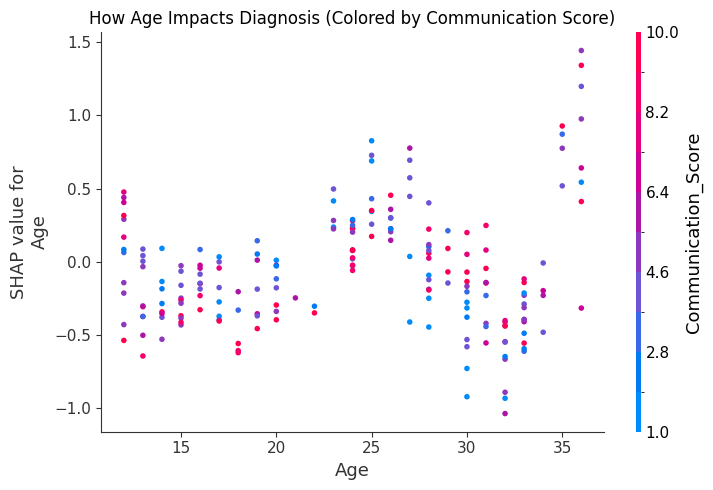

In [ ]:
# Initialize the SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Set up the plot styling
plt.style.use('default')

# SHAP Summary Plot (Feature Importance)
# This shows which features drive the diagnosis the most
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, show=False)
plt.title("What Drives an ASD Diagnosis?")
plt.tight_layout()
plt.show()

# SHAP Dependence Plot for Age vs. Communication
# This directly answers the research question: How does age affect behavior scores?
print("\nGenerating Age vs. Communication Interaction Plot...")
shap.dependence_plot(
    "Age",
    shap_values,
    X_test,
    interaction_index="Communication_Score",
    show=False
)
plt.title("How Age Impacts Diagnosis (Colored by Communication Score)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1964/4071787166.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Dev_Phase', palette='Blues', ax=axes[0])
/tmp/ipykernel_1964/4071787166.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shap_df, x='Dev_Phase', y='Age_SHAP_Impact', palette='Oranges', ax=axes[1])


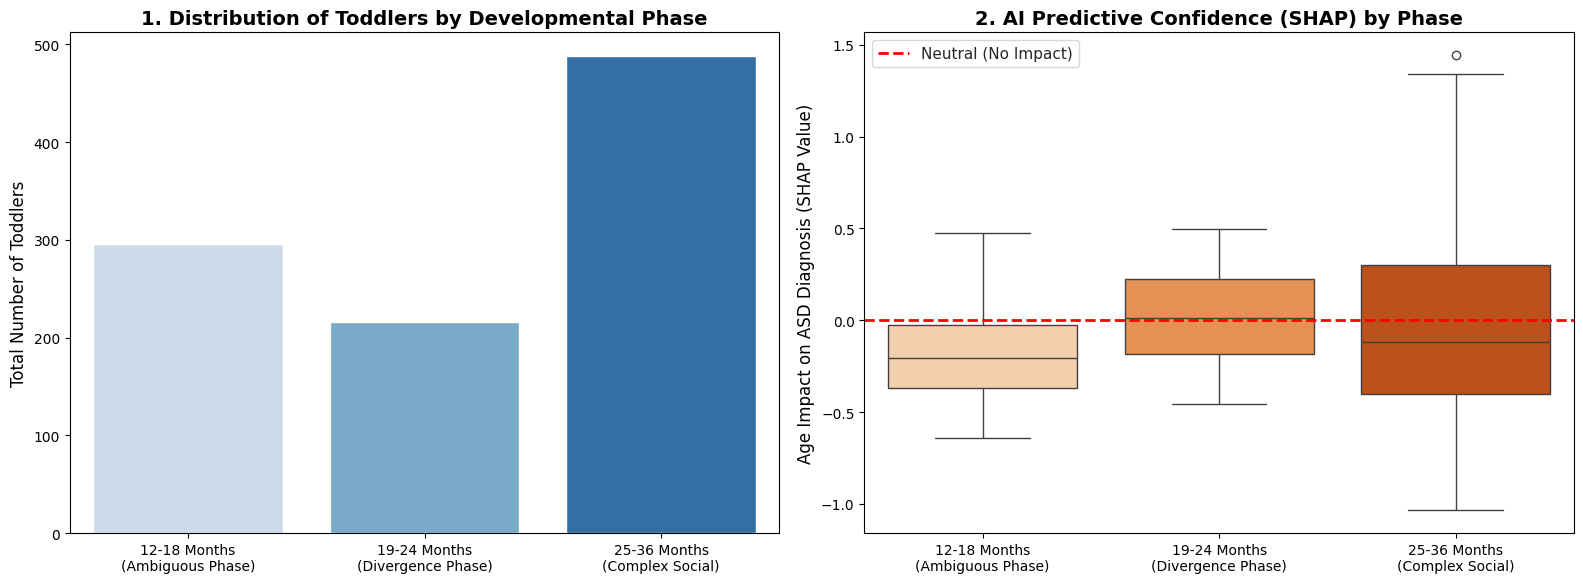

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define our 3 Clinical Developmental Bins
bins = [11, 18, 24, 37] # Bins for 12-18m, 19-24m, and 25-36m
labels = ['12-18 Months\n(Ambiguous Phase)', '19-24 Months\n(Divergence Phase)', '25-36 Months\n(Complex Social)']

# Add the phases to the FULL dataset (for our demographic distribution plot)
df['Dev_Phase'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 2. Extract SHAP data to prove our AI explanation
# Age is the 5th feature in our X_test dataframe, which is index 4
age_shap_values = shap_values[:, 4]

# Create a clean dataframe for the SHAP analysis
shap_df = X_test.copy()
shap_df['Dev_Phase'] = pd.cut(shap_df['Age'], bins=bins, labels=labels)
shap_df['Age_SHAP_Impact'] = age_shap_values

# 3. Create a beautiful side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot A: Dataset Distribution ---
sns.countplot(data=df, x='Dev_Phase', palette='Blues', ax=axes[0])
axes[0].set_title("1. Distribution of Toddlers by Developmental Phase", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Number of Toddlers", fontsize=12)
axes[0].set_xlabel("")

# --- Plot B: AI Predictive Power (SHAP Impact) ---
sns.boxplot(data=shap_df, x='Dev_Phase', y='Age_SHAP_Impact', palette='Oranges', ax=axes[1])
# Add a red dashed line at zero (where Age has no impact on the diagnosis)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Neutral (No Impact)')
axes[1].set_title("2. AI Predictive Confidence (SHAP) by Phase", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Age Impact on ASD Diagnosis (SHAP Value)", fontsize=12)
axes[1].set_xlabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

**12–18 Months (The Ambiguous Phase):**

- Typical Development: Neurotypical toddlers are just learning single words, making eye contact, and maybe pointing.

- Why the AI struggles (SHAP drops below 0): Behaviors are very ambiguous here. Both neurotypical and autistic toddlers might ignore their names or throw tantrums. The model knows it cannot confidently diagnose ASD based purely on a lack of language at this age.

**19–24 Months (The "Language Explosion" Divergence):**

- Typical Development: Neurotypical toddlers start stringing two words together, playing pretend, and actively seeking social engagement.

- Why the AI wakes up (SHAP starts climbing): This is when the developmental paths sharply diverge. If a 24-month-old is not making eye contact or trying to communicate, the absence of those milestones becomes highly predictive of ASD.

**25–36 Months (The Complex Social Phase):**

- Typical Development: Neurotypical toddlers are engaging in complex social play, forming sentences, and showing empathy.

- Why the AI is highly confident (SHAP spikes to the top): By 36 months, the "grace period" for late blooming is mostly over. If a child at this age has high repetitive behaviors and low social interaction, the AI heavily relies on their age to confidently lock in an ASD diagnosis.